# 00 · Data preparation (pipeline inputs)

How the cleaned tables become Boltz-2 inputs: the per-target **protein construct**, the **MSA**, the per-compound **YAML**, the **nested train/eval split**, and the **chunking** used for SLURM array jobs. This is the input side of the ~50k-compound co-folding step.

In [1]:
import os, gzip, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_columns", 40)

ROOT = Path("/global/scratch/users/sergiomar10/boltzaff")
RAW  = ROOT / "data" / "mf-pcba_test"       # distributed per-target CSVs
DATA = ROOT / "data"                        # our cleaned CSVs + seqs + MSAs
SPLITS = ROOT / "BoltzFT" / "data" / "splits"

# target folder -> (protein, source structure/GI)
TARGETS = {
 "588689":         ("Dengue-2 NS5 MTase",      "PDB 3EVG"),
 "540297-493091":  ("SCP1 phosphatase",        "PDB 3PGL"),
 "434954-2097":    ("GSK-3\u03b2",               "PDB 1J1B"),
 "463203-2650":    ("GSK-3\u03b1",               "PDB 7SXF"),
 "493248-485317":  ("ALR / GFER oxidase",      "PDB 3MBG"),
 "504329":         ("Influenza A NS1",         "predicted (GI 227977143)"),
 "624273-588549":  ("M.tb FadD28 ligase",      "predicted (GI 1781172)"),
 "1053173-743445": ("NSD2 PWWP1 domain",       "PDB 6UE6"),
}

# Paper Table 1 (Furui & Ohue, arXiv:2609.24302), for validation.
# target -> dict(neval, nactive_eval, active_rate_pct, train_actives {40,100,300})
PAPER_T1 = {
 "588689":        dict(neval=49685, nact=396, rate=0.80, tr={40:16,100:32,300:90}),
 "540297-493091": dict(neval=49685, nact=739, rate=1.49, tr={40:8, 100:16,300:43}),
 "434954-2097":   dict(neval=49615, nact=415, rate=0.84, tr={40:24,100:52,300:107}),
 "463203-2650":   dict(neval=49582, nact=542, rate=1.09, tr={40:13,100:29,300:70}),
 "493248-485317": dict(neval=49680, nact=953, rate=1.92, tr={40:1, 100:9, 300:23}),
 "504329":        dict(neval=49682, nact=438, rate=0.88, tr={40:4, 100:11,300:28}),
 "624273-588549": dict(neval=49687, nact=150, rate=0.30, tr={40:4, 100:4, 300:9}),
 "1053173-743445":dict(neval=49695, nact=134, rate=0.27, tr={40:0, 100:5, 300:10}),
}

def load_split_order(t):
    """Return the score_boltz2-descending CID ranking shipped in data/splits."""
    p = SPLITS / f"{t}.txt.gz"
    with gzip.open(p, "rt") as f:
        return [int(x.strip().removeprefix(t + "_")) for x in f]


In [2]:
import matplotlib as mpl, matplotlib.pyplot as plt
PALETTE = ["#2a78d6","#eb6834","#1baf7a","#eda100","#e87ba4","#008300","#4a3aa7","#e34948"]
INK, MUTED, SURF = "#0b0b0b", "#52514e", "#fcfcfb"
ACTIVE, INACTIVE, BLUE = "#e34948", "#b8b6ad", "#2a78d6"
TCOLOR = {t: PALETTE[i] for i, t in enumerate(TARGETS)}   # fixed hue per target
mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 10,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 100})


## Protein constructs
Construct sequences are **not** distributed with the data; we reconstructed them from the reference structures named in the Boltzina paper (6 PDBs) and from NCBI for the 2 predicted-holo targets. Two assignments were cross-checked against PubChem BioAssay targets.

In [3]:
rows=[]
for t,(prot,src) in TARGETS.items():
    sp = DATA / f"{t}_seq.txt"
    seq = sp.read_text().strip() if sp.exists() else ""
    rows.append({"target": t, "protein": prot, "source": src, "construct_len": len(seq)})
pd.DataFrame(rows)

,target,protein,source,construct_len
0,588689,Dengue-2 NS5 MTase,PDB 3EVG,275
1,540297-493091,SCP1 phosphatase,PDB 3PGL,180
2,434954-2097,GSK-3β,PDB 1J1B,420
3,463203-2650,GSK-3α,PDB 7SXF,345
4,493248-485317,ALR / GFER oxidase,PDB 3MBG,139
5,504329,Influenza A NS1,predicted (GI 227977143),219
6,624273-588549,M.tb FadD28 ligase,predicted (GI 1781172),580
7,1053173-743445,NSD2 PWWP1 domain,PDB 6UE6,141


## MSA depth
One MSA per target (colabfold MMseqs2), shared across all of that target's compounds — exactly the paper's setup.

In [4]:
rows=[]
for t in TARGETS:
    mp = DATA / f"{t}_msa.csv"
    if mp.exists():
        n = sum(1 for _ in open(mp)) - 1
        rows.append({"target": t, "protein": TARGETS[t][0], "msa_sequences": n})
    else:
        rows.append({"target": t, "protein": TARGETS[t][0], "msa_sequences": "(generating)"})
pd.DataFrame(rows)

,target,protein,msa_sequences
0,588689,Dengue-2 NS5 MTase,1028
1,540297-493091,SCP1 phosphatase,13025
2,434954-2097,GSK-3β,16384
3,463203-2650,GSK-3α,14186
4,493248-485317,ALR / GFER oxidase,8190
5,504329,Influenza A NS1,279
6,624273-588549,M.tb FadD28 ligase,10990
7,1053173-743445,NSD2 PWWP1 domain,6627


## Example Boltz-2 input YAML
Protein (with shared MSA) + ligand SMILES + affinity binder request.

In [5]:
import glob
y = sorted(glob.glob(str(ROOT/"results/runs/588689/inputs_full/*.yaml")))
print(Path(y[0]).name if y else "(inputs not built yet)")
if y:
    txt = Path(y[0]).read_text()
    # trim the long sequence/MSA path for display
    print("\n".join(l[:90] for l in txt.splitlines()))

588689_1000020.yaml
version: 1
sequences:
- protein:
    id:
    - A
    sequence: MTGNIGETLGEKWKSRLNALGKSEFQIYKKSGIQEVDRTLAKEGIKRGETDHHAVSRGSAKLRWFVERNMVTPEGK
    msa: /global/scratch/users/sergiomar10/boltzaff/data/588689_msa.csv
- ligand:
    id:
    - B
    smiles: COc1ccc(N(CC(=O)NC2CC2)S(=O)(=O)c2ccccc2)cc1
properties:
- affinity:
    binder: B


## Nested train / eval split
Training sets are the top-N of the Boltz-2 ranking and are **nested** (40 \u2282 100 \u2282 300). The common evaluation set is everything below rank 300. The last 20 of the ranking are held out for validation during fine-tuning.

In [6]:
t="588689"
df = pd.read_csv(DATA/f"{t}_results.csv").set_index("CID").loc[load_split_order(t)].reset_index()
df["rank"]=np.arange(1,len(df)+1)
for n in (40,100,300):
    tr=df.iloc[:n]
    print(f"train top{n:<3d}: {len(tr):3d} compounds, {int(tr.Active_v2.sum())} active")
print(f"eval set  : rank 301..{len(df)} = {len(df)-300} compounds, {int(df.iloc[300:].Active_v2.sum())} active")
print(f"validation: last 20 of ranking (held out during FT)")

train top40 :  40 compounds, 16 active
train top100: 100 compounds, 32 active
train top300: 300 compounds, 90 active
eval set  : rank 301..49985 = 49685 compounds, 396 active
validation: last 20 of ranking (held out during FT)


## Chunking for SLURM arrays
Inputs are split into 350-compound chunks; each chunk is one GPU array task for Pass-1 co-folding. Pass-1 is the compute bottleneck (~26 s/compound &rarr; ~360 GPU-h/target).

In [7]:
for t in TARGETS:
    ct = ROOT/f"results/runs/{t}/chunks.tsv"
    if ct.exists():
        n=sum(1 for _ in open(ct)); print(f"{t:16s} {n} chunks x 350")
    else:
        print(f"{t:16s} (not chunked yet)")

588689           143 chunks x 350
540297-493091    143 chunks x 350
434954-2097      143 chunks x 350
463203-2650      143 chunks x 350
493248-485317    143 chunks x 350
504329           143 chunks x 350
624273-588549    143 chunks x 350
1053173-743445   143 chunks x 350


### Pipeline order
`select_subsets` &rarr; `build_boltz_inputs` &rarr; `make_chunks` &rarr; **Pass-1** co-folding (`--write_embeddings_cropped --skip_affinity_prediction`) &rarr; `merge_consolidate` + `build_ft_inputs_full` &rarr; **Pass-2** affinity cache (reuses poses) &rarr; multi-seed head-FT train + score &rarr; evaluation.

## Construct length and MSA depth per target
Left: reconstructed protein construct lengths. Right: number of MSA sequences (colabfold), shared across every compound of that target. Deeper MSA generally = more reliable co-folding.

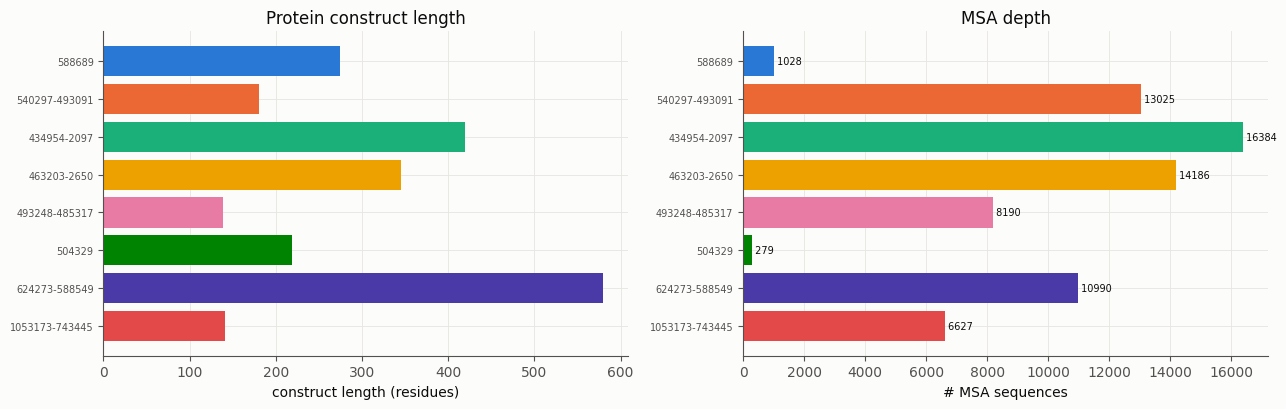

In [8]:
lens, depths, labels, colors = [], [], [], []
for t in TARGETS:
    sp, mp = DATA/f"{t}_seq.txt", DATA/f"{t}_msa.csv"
    lens.append(len(sp.read_text().strip()) if sp.exists() else 0)
    depths.append((sum(1 for _ in open(mp))-1) if mp.exists() else 0)
    labels.append(t); colors.append(TCOLOR[t])
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.2))
a1.barh(range(8), lens, color=colors); a1.set_yticks(range(8)); a1.set_yticklabels(labels, fontsize=7)
a1.invert_yaxis(); a1.set_xlabel("construct length (residues)"); a1.set_title("Protein construct length")
a2.barh(range(8), depths, color=colors); a2.set_yticks(range(8)); a2.set_yticklabels(labels, fontsize=7)
a2.invert_yaxis(); a2.set_xlabel("# MSA sequences"); a2.set_title("MSA depth")
for i,v in enumerate(depths): a2.text(v, i, f" {v}", va="center", fontsize=7)
plt.tight_layout(); plt.show()